In [1]:
# from google.colab import drive
import torch
import sys
import numpy as np
import math
import time
import torch.nn.functional as F
from transformers import get_cosine_schedule_with_warmup
# drive.mount('/content/gdrive', force_remount=True)


#base_dir = "/content/gdrive/MyDrive/Junior/Second Semester/CS 6787 - Advanced ML Systems/Final Project"
# base_dir = "/content/gdrive/MyDrive/Final Project"
base_dir = ""
# sys.path.append(base_dir)

device = torch.device("cuda" if torch.cuda.is_available()
                else ("mps" if torch.backends.mps.is_available()
                else "cpu"))
#device = torch.device("meta")
print(F"Device set to {device}")
print("Loading GPT2 model...")

Device set to cuda
Loading GPT2 model...


In [6]:
!pwd

/content


In [7]:
import sys
import importlib

# 1. Force remove the old module from the cache
if 'GPT2' in sys.modules:
    del sys.modules['GPT2']

In [8]:
import os
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

In [2]:
import importlib
import Datasets.DataLoader as DataLoader_Lib
# from Models.GPT_Model import GPT2, GPTConfig
from Models.LagBehind_Model import GPT2_Lag
import Models.GPT_Model as GPT_Model
import Models.LagBehind_Model as LagBehind_Model

importlib.reload(GPT_Model)
importlib.reload(LagBehind_Model)
importlib.reload(DataLoader_Lib)

from Models.GPT_Model import GPT2, GPTConfig
from Models.LagBehind_Model import GPT2_Lag, LagBehindGPTConfig

from Datasets.DataLoader import TinyShakespeareDataLoader, TinyStoriesDataLoader, CombinedBinDataLoader

In [3]:
B = 32 # Adjust batch size based on your Colab GPU memory
SL = 256
config = LagBehindGPTConfig(num_heads = 6,
  num_layers = 6,
  vocab_size = 50257,
  embedding_dim = 768,
  block_size = SL,
  lag_behind = 1,
  dropout = .1)

model = GPT2_Lag(config, device)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.95),   # default is (0.9, 0.999)
    eps=1e-8,            # numerical stability, default is fine
    weight_decay=0.1
)

# Config = GPTConfig(num_heads = 12,
#   num_layers = 12,
#   vocab_size = 50257,
#   embedding_dim = 768,
#   block_size = block_size,
#   lag_behind = 1,
#   dropout = .1,
#   pad_token_id=loader.pad_token())

# model = GPT2_Lag(Config, device)
# model.to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [4]:
import torch
import numpy as np

class CombinedBinDataLoader:
    def __init__(self, filename, B, SL, config, split='train'):
        self.B = B
        self.SL = SL
        self.config = config
        
        # Memory-map the binary file (stays on disk, essentially 0 RAM usage)
        self.data = np.memmap(filename, dtype=np.uint16, mode='r')
        
        # Calculate the 90% split index
        n = int(0.9 * len(self.data))
        
        if split == 'train':
            self.split_data = self.data[:n]
        else:
            self.split_data = self.data[n:]
            
        self.cursor = 0
        print(f"Initialized {split} loader with {len(self.split_data):,} tokens.")

    def get_data(self):
        # 1. Fetch the continuous chunk from disk and convert to torch.long (int64)
        chunk = self.split_data[self.cursor : self.cursor + self.B * self.SL + 1]
        buf = torch.from_numpy(chunk.astype(np.int64))
        
        # 2. Standard autoregressive shifting
        x = buf[:-1].view(self.B, self.SL)
        y = buf[1:].view(self.B, self.SL)
        
        # 3. --- Y2 LAG BEHIND LOGIC ---
        k = self.config.lag_behind
        shift = k 

        # Fill with -100 (PyTorch's default ignore_index for Cross Entropy)
        y2 = torch.full_like(x, -100) 

        # Shift the sequence to the right by 'shift' steps
        if shift > 0:
            y2[:, shift:] = x[:, :-shift]
        elif shift == 0:
            y2 = x.clone()

        # 4. Advance the cursor for the next batch
        self.cursor += self.B * self.SL
        
        # Reset cursor if we hit the end of our split
        if self.cursor + (self.B * self.SL + 1) > len(self.split_data):
            self.cursor = 0
            
        return x, y, y2

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!cp "/content/drive/MyDrive/fineweb_1B.bin" "/content/finweb_1B.bin"

In [8]:
train_loader = CombinedBinDataLoader(
    '/content/finweb_1B.bin',
    B, SL, config=config, split='train'
)

Initialized train loader with 900,000,157 tokens.


In [9]:
val_loader = CombinedBinDataLoader('/content/finweb_1B.bin', B, SL, config, split='val')

Initialized val loader with 100,000,018 tokens.


In [10]:
import math

In [11]:
@torch.no_grad()
def estimate_loss(model, loader, device, eval_iters=10):
    model.eval()
    fwd_losses = torch.zeros(eval_iters)
    bwd_losses = torch.zeros(eval_iters)
    loader.cursor = 0

    for k in range(eval_iters):
        x, y, _ = loader.get_data()
        x, y = x.to(device), y.to(device)

        logits_fwd, logits_lag, _ = model(x, y)

        V         = model.config.vocab_size
        skip_dist = model.config.lag_behind
        half      = x.size(0) // 2

        fwd_losses[k] = F.cross_entropy(
            logits_fwd.view(-1, V),
            y[:half].view(-1)
        ).item()

        bwd_targets = x[half:, :-skip_dist]
        bwd_logits  = logits_lag[:, skip_dist:]
        bwd_losses[k] = F.cross_entropy(
            bwd_logits.reshape(-1, V),
            bwd_targets.reshape(-1)
        ).item()

    model.train()
    avg_fwd = fwd_losses.mean().item()
    avg_bwd = bwd_losses.mean().item()
    ppl     = torch.exp(torch.tensor(avg_fwd)).item()
    return avg_fwd, ppl, avg_bwd

def get_lr(step, num_steps_train, warmup_steps=1000, max_lr=3e-4, min_lr=3e-5):
    if step < warmup_steps:
        return max_lr * (step / warmup_steps)
    return min_lr + 0.5 * (max_lr - min_lr) * (
        1 + math.cos(math.pi * (step - warmup_steps) / (num_steps_train - warmup_steps))
    )

tokens_per_step = train_loader.B * train_loader.SL
# def train_loop(model, optimizer, device, train_loader, val_loader,
#                num_steps_train, num_steps_val, lam=0.5):

#     print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

#     fwd_loss, ppl, bwd_loss = estimate_loss(model, val_loader, device, num_steps_val)
#     print(f"Step    0 | Val FWD: {fwd_loss:.4f} | PPL: {ppl:.2f} | Val BWD: {bwd_loss:.4f}")

#     tokens_seen = 0
#     for step in range(num_steps_train):

#         if step % 100 == 0 and step > 0:
#             fwd_loss, ppl, bwd_loss = estimate_loss(model, val_loader, device, num_steps_val)
#             print(f"Step {step:4d} | Val FWD: {fwd_loss:.4f} | PPL: {ppl:.2f} | Val BWD: {bwd_loss:.4f}")

#         lr = get_lr(step, num_steps_train)
#         for param_group in optimizer.param_groups:
#             param_group['lr'] = lr

#         x, y, _ = train_loader.get_data()
#         x, y = x.to(device), y.to(device)

#         optimizer.zero_grad()
#         _, _, loss = model(x, y, lam=lam)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # missing
#         optimizer.step()
#         tokens_seen += tokens_per_step
#         if step % 10 == 0:
#             print(f"step {step:4d} | tokens {tokens_seen:,} | train loss {loss.item():.4f}")

from torch.cuda.amp import autocast, GradScaler

def train_loop(model, optimizer, device, train_loader, val_loader,
               num_steps_train, num_steps_val, lam=0.5):

    scaler = GradScaler()
    tokens_per_step = train_loader.B * train_loader.SL
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    history = {
        'train_steps': [],
        'train_loss':  [],
        'val_steps':   [],
        'val_loss':    [],
        'val_ppl':     []
    }

    fwd_loss, ppl, bwd_loss = estimate_loss(model, val_loader, device, num_steps_val)
    print(f"Step    0 | Val FWD: {fwd_loss:.4f} | PPL: {ppl:.2f} | Val BWD: {bwd_loss:.4f}")
    history['val_steps'].append(0)
    history['val_loss'].append(fwd_loss)
    history['val_ppl'].append(ppl)

    tokens_seen = 0
    for step in range(num_steps_train):

        if step % 100 == 0 and step > 0:
            fwd_loss, ppl, bwd_loss = estimate_loss(model, val_loader, device, num_steps_val)
            print(f"Step {step:4d} | Val FWD: {fwd_loss:.4f} | PPL: {ppl:.2f} | Val BWD: {bwd_loss:.4f}")
            history['val_steps'].append(step)
            history['val_loss'].append(fwd_loss)
            history['val_ppl'].append(ppl)

        lr = get_lr(step, num_steps_train)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        x, y, _ = train_loader.get_data()
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        with autocast():
            _, _, loss = model(x, y, lam=lam)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        tokens_seen += tokens_per_step
        if step % 10 == 0:
            history['train_steps'].append(step)
            history['train_loss'].append(loss.item())
            print(f"step {step:4d} | tokens {tokens_seen:,} | lr {lr:.2e} | train loss {loss.item():.4f}")

        if step % 5000 == 0 and step > 0:
            save_checkpoint(model, optimizer, step, loss,
                f'/content/drive/MyDrive/checkpoint_step{step}.pt')

    return history

In [12]:
print(f"Train tokens: {len(train_loader.split_data):,}")
print(f"Val tokens:   {len(val_loader.split_data):,}")
print(f"Tokens per step: {train_loader.B * train_loader.SL:,}")

Train tokens: 900,000,157
Val tokens:   100,000,018
Tokens per step: 8,192


In [12]:
def save_checkpoint(model, optimizer, step, loss, path):
    torch.save({
        'step': step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)

def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return checkpoint['step'], checkpoint['loss']

In [13]:
import json
num_steps_train = 50000
num_steps_val = 10
history = train_loop(model, optimizer, device, train_loader, val_loader,num_steps_train, num_steps_val)

with open('/content/drive/MyDrive/vanilla_history.json', 'w') as f:
    json.dump(history, f)

/tmp/ipython-input-3469547155.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Trainable parameters: 119,920,128
Step    0 | Val FWD: 10.9946 | PPL: 59552.22 | Val BWD: 10.9983


/tmp/ipython-input-3469547155.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


step    0 | tokens 8,192 | lr 0.00e+00 | train loss 10.9970
step   10 | tokens 90,112 | lr 3.00e-06 | train loss 10.9808
step   20 | tokens 172,032 | lr 6.00e-06 | train loss 10.8837
step   30 | tokens 253,952 | lr 9.00e-06 | train loss 10.7173
step   40 | tokens 335,872 | lr 1.20e-05 | train loss 10.4853
step   50 | tokens 417,792 | lr 1.50e-05 | train loss 10.2298
step   60 | tokens 499,712 | lr 1.80e-05 | train loss 9.9582
step   70 | tokens 581,632 | lr 2.10e-05 | train loss 9.8073
step   80 | tokens 663,552 | lr 2.40e-05 | train loss 9.5822
step   90 | tokens 745,472 | lr 2.70e-05 | train loss 9.4579
Step  100 | Val FWD: 9.1177 | PPL: 9115.08 | Val BWD: 9.1231
step  100 | tokens 827,392 | lr 3.00e-05 | train loss 9.2162
step  110 | tokens 909,312 | lr 3.30e-05 | train loss 9.0577
step  120 | tokens 991,232 | lr 3.60e-05 | train loss 8.8738
step  130 | tokens 1,073,152 | lr 3.90e-05 | train loss 8.5576
step  140 | tokens 1,155,072 | lr 4.20e-05 | train loss 8.2697
step  150 | token

In [39]:
import torch
import gc

# 1. Delete the model variable
if 'model' in globals():
    del model

# 2. Clear the Python garbage collector
gc.collect()

# 3. Empty the PyTorch VRAM cache
torch.cuda.empty_cache()

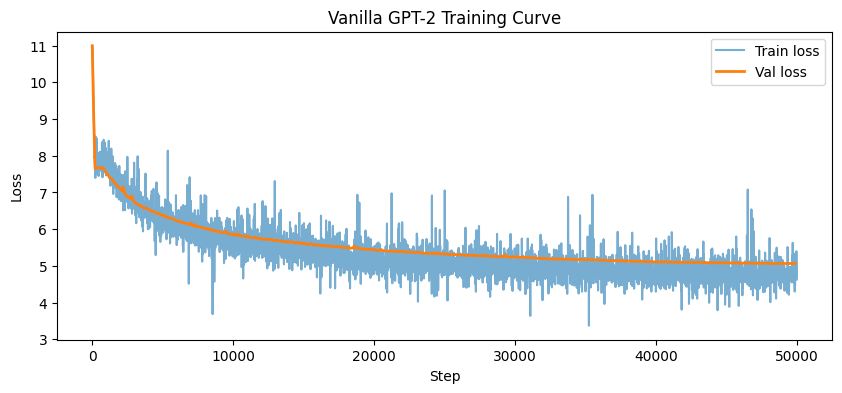

In [14]:
import matplotlib.pyplot as plt
import json

with open('/content/drive/MyDrive/vanilla_history.json') as f:
    history = json.load(f)

plt.figure(figsize=(10, 4))
plt.plot(history['train_steps'], history['train_loss'], label='Train loss', alpha=0.6)
plt.plot(history['val_steps'], history['val_loss'], label='Val loss', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.title('Vanilla GPT-2 Training Curve')
plt.savefig('/content/drive/MyDrive/vanilla_curve.png')
plt.show()